In [ ]:
import polars as pl
import mlflow
import numpy as np
import shap

shap.plots.initjs()

c:\Users\georg\Documents\GitHub\nba-win-probability-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
INDEX_COLUMNS = [
    "evt",
    "opt1",
    "opt2",
    "opt3",
    "opt4",
    "mtype",
    "etype",
    "opid",
    "tid",
    "pid",
    "hs",
    "vs",
    "epid",
    "oftid",
    "ord",
    "HOME_Team_ID",
    "AWAY_Team_ID",
    # "PERIOD",
]
Y_COL = "home_win"

def prepare_data(df: pl.DataFrame) -> pl.DataFrame:
    """Prepare the data by converting columns to appropriate types."""
    return (
        df.with_columns(
            pl.col("gametime_elapsed").sub(pl.datetime(1970, 1, 1)).dt.total_seconds()
        )
        .select(pl.col(pl.NUMERIC_DTYPES))
        .drop(INDEX_COLUMNS)
    ).drop_nulls()


def split_train_test_cols(df: pl.DataFrame) -> tuple[pl.DataFrame, np.ndarray]:
    """Split the dataframe into features and target variable."""
    X = df.select(pl.exclude(Y_COL))
    y = df[Y_COL].to_numpy()

    return X, y

def load_and_prep_data(path: str) -> tuple[pl.DataFrame, np.ndarray]:
    df = pl.read_parquet(path)
    clean_df = prepare_data(df)

    return split_train_test_cols(clean_df)

In [ ]:
X_train, y_train = load_and_prep_data(r"C:\Users\georg\Documents\GitHub\nba-win-probability-model\data\processed\resampled_train_22.parquet")
X_test, y_test = load_and_prep_data(r"C:\Users\georg\Documents\GitHub\nba-win-probability-model\data\processed\resampled_test_23.parquet")

C:\Users\georg\AppData\Local\Temp\ipykernel_9428\2807353019.py:29: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES))


In [4]:
model_uri = "runs:/{}/model".format('db3e0f6f51b94422bd3b91b933c929d8')
model = mlflow.sklearn.load_model(model_uri)


2026/01/31 15:08:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/31 15:08:03 INFO mlflow.store.db.utils: Updating database tables
2026/01/31 15:08:03 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/31 15:08:03 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/31 15:08:06 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/31 15:08:06 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [41]:
explainer = shap.Explainer(model.named_steps['rfecv'].predict_proba, model.named_steps['scaler'].transform(X_train), feature_names=X_train.columns)

c:\Users\georg\Documents\GitHub\nba-win-probability-model\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [42]:
sampled_X_test = X_test.sample(20)
shap_values = explainer(model.named_steps['scaler'].transform(sampled_X_test))[:,:,1]
shap_values.data = sampled_X_test.to_numpy()

c:\Users\georg\Documents\GitHub\nba-win-probability-model\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


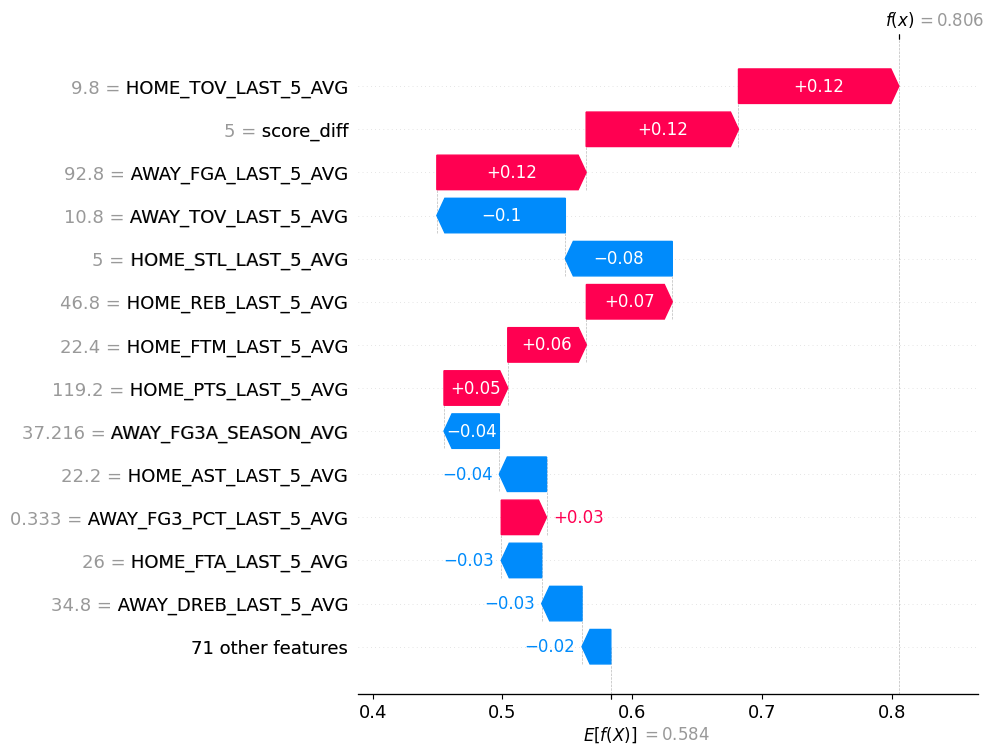

In [44]:
shap.plots.waterfall(shap_values[4], max_display=14)

This plot is interesting, I might have more luck having fta and ft% vs fta and ftm as they're more likely to be strongly correlated.

Think I need more interactions terms:
- % vs makes and attempts
- % difference compared to season averages?

In [45]:
shap.plots.force(shap_values[4])

In [49]:
model.named_steps['rfecv'].get_feature_names_out()

array(['x5', 'x19', 'x27', 'x33', 'x36', 'x37', 'x41', 'x42', 'x43',
       'x44', 'x51', 'x52', 'x63', 'x68', 'x71', 'x72', 'x73', 'x78',
       'x81', 'x83'], dtype=object)